In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
FECHA_INICIO = "2025-01-01"
FECHA_FIN = "2025-12-31"

# mediciones por dia
N_POR_DIA = 10

# Semilla
np.random.seed(42)

print("se obtendra", 365*N_POR_DIA, "ejemplos")

se obtendra 3650 ejemplos


In [13]:
# creacion de fechas
dias = pd.date_range(
    start=FECHA_INICIO,
    end=FECHA_FIN,
    freq="D"
)

fechas = []

for dia in dias:

    #  se distribuir las mediciones durante las 24 horas
    horas = np.linspace(
        0,
        24,
        N_POR_DIA,
        endpoint=False
    )

    for hora in horas:

        fecha_medicion = dia + pd.Timedelta(hours=float(hora))
        fechas.append(fecha_medicion)


cantidad_registros = len(fechas)

print("Cantidad de días:", len(dias))
print("Mediciones por día:", N_POR_DIA)
print("Total de registros:", cantidad_registros)

Cantidad de días: 365
Mediciones por día: 10
Total de registros: 3650


In [14]:
# generacion de datos sinteticos
n = cantidad_registros

# Tiempo normalizado
t = np.arange(n)


# pH
# Rango aceptable: 6.5 - 9.5
ph = (
    7.5
    + 0.4 * np.sin(t / 150)
    + np.random.normal(0, 0.15, n)
)

ph = np.clip(ph, 6.5, 9.5)


# Turbidez
# Máximo recomendado: 5

turbidez = (
    2
    + 1.2 * np.sin(t / 100)
    + np.random.normal(0, 0.5, n)
)

turbidez = np.clip(turbidez, 0, 7)


# Color
# Máximo recomendado: 15

color = (
    7
    + 3 * np.sin(t / 200)
    + np.random.normal(0, 1.5, n)
)

color = np.clip(color, 0, 20)


# Sólidos disueltos totales (SDT)
# Máximo recomendado: 1000

sdt = (
    450
    + 150 * np.sin(t / 300)
    + np.random.normal(0, 60, n)
)

sdt = np.clip(sdt, 100, 1200)


# Nitratos (NO3)
# Máximo recomendado: 45

no3 = (
    20
    + 8 * np.sin(t / 250)
    + np.random.normal(0, 4, n)
)

no3 = np.clip(no3, 0, 55)


# Arsénico
# Máximo recomendado: 0.01

arsenico = (
    0.004
    + 0.002 * np.sin(t / 180)
    + np.random.normal(0, 0.001, n)
)

arsenico = np.clip(arsenico, 0, 0.015)


# Plomo
# Máximo recomendado: 0.01

plomo = (
    0.003
    + np.random.normal(0, 0.0015, n)
)

plomo = np.clip(plomo, 0, 0.015)


# E. coli
#
# 0 = ausencia
# 1 = presencia
#
# La mayoría de las muestras estarán libres de E. coli.

ecoli = np.random.choice(
    [0, 1],
    size=n,
    p=[0.97, 0.03]
)

In [15]:

# CREACIÓN DEL DATASET

df = pd.DataFrame({
    "fecha": fechas,
    "ph": ph,
    "turbidez": turbidez,
    "color": color,
    "sdt": sdt,
    "no3": no3,
    "arsenico": arsenico,
    "plomo": plomo,
    "ecoli": ecoli
})


print(df.head())

                          fecha        ph  turbidez     color         sdt  \
0 2025-01-01 00:00:00.000000000  7.574507  2.204026  6.008462  408.422580   
1 2025-01-01 02:24:00.000000000  7.481927  2.287399  6.242592  512.065246   
2 2025-01-01 04:48:00.000000000  7.602486  2.246385  6.344953  501.627394   
3 2025-01-01 07:11:59.999999999  7.736454  1.623168  7.553489  470.465244   
4 2025-01-01 09:36:00.000000000  7.475542  2.122669  7.744370  411.767351   

         no3  arsenico     plomo  ecoli  
0  25.321374  0.005312  0.003363      0  
1  27.583436  0.003165  0.003410      0  
2  21.388890  0.003291  0.005381      0  
3  22.123208  0.004227  0.002137      0  
4  11.595257  0.003674  0.002666      0  


In [16]:
# SUMA DE LOS PARÁMETROS

columnas_calidad = [
    "ph",
    "turbidez",
    "color",
    "sdt",
    "no3",
    "arsenico",
    "plomo",
    "ecoli"
]


df["suma_total"] = df[columnas_calidad].sum(axis=1)


df[[
    "fecha",
    "suma_total"
]].head()

,fecha,suma_total
0,2025-01-01 00:00:00.000000000,449.539624
1,2025-01-01 02:24:00.000000000,555.667174
2,2025-01-01 04:48:00.000000000,539.218781
3,2025-01-01 07:11:59.999999999,509.507927
4,2025-01-01 09:36:00.000000000,440.711529


In [17]:

# CALIDAD DEL AGUA: ESCALA 0 - 10

suma_min = df["suma_total"].min()
suma_max = df["suma_total"].max()


df["calidad_agua"] = 10 * (
    1 -
    (
        (df["suma_total"] - suma_min)
        /
        (suma_max - suma_min)
    )
)


# Limitar por seguridad entre 0 y 10
df["calidad_agua"] = df["calidad_agua"].clip(0, 10)


print(
    df[
        [
            "fecha",
            "suma_total",
            "calidad_agua"
        ]
    ].head()
)

                          fecha  suma_total  calidad_agua
0 2025-01-01 00:00:00.000000000  449.539624      5.906045
1 2025-01-01 02:24:00.000000000  555.667174      4.328346
2 2025-01-01 04:48:00.000000000  539.218781      4.572869
3 2025-01-01 07:11:59.999999999  509.507927      5.014552
4 2025-01-01 09:36:00.000000000  440.711529      6.037284


In [ ]:

# REDONDEAR VALORES

df["ph"] = df["ph"].round(2)
df["turbidez"] = df["turbidez"].round(2)
df["color"] = df["color"].round(2)
df["sdt"] = df["sdt"].round(2)
df["no3"] = df["no3"].round(2)

df["arsenico"] = df["arsenico"].round(5)
df["plomo"] = df["plomo"].round(5)

df["suma_total"] = df["suma_total"].round(3)
df["calidad_agua"] = df["calidad_agua"].round(2)


df.head(10)

,fecha,ph,turbidez,color,sdt,no3,arsenico,plomo,ecoli,suma_total,calidad_agua
0,2025-01-01 00:00:00.000000000,7.57,2.20,6.01,408.42,25.32,0.00531,0.00336,0,449.540,5.91
1,2025-01-01 02:24:00.000000000,7.48,2.29,6.24,512.07,27.58,0.00317,0.00341,0,555.667,4.33
2,2025-01-01 04:48:00.000000000,7.60,2.25,6.34,501.63,21.39,0.00329,0.00538,0,539.219,4.57
3,2025-01-01 07:11:59.999999999,7.74,1.62,7.55,470.47,22.12,0.00423,0.00214,0,509.508,5.01
4,2025-01-01 09:36:00.000000000,7.48,2.12,7.74,411.77,11.60,0.00367,0.00267,0,440.712,6.04
5,2025-01-01 12:00:00.000000000,7.48,2.24,2.51,443.42,28.56,0.00628,0.00284,0,484.212,5.39
6,2025-01-01 14:23:59.999999999,7.75,2.08,8.62,323.78,17.89,0.00390,0.00470,0,360.134,7.24
7,2025-01-01 16:48:00.000000000,7.63,1.04,9.26,466.96,16.49,0.00441,0.00502,0,501.398,5.14
8,2025-01-01 19:12:00.000000000,7.45,2.18,5.54,474.98,19.24,0.00503,0.00371,0,509.392,5.02
9,2025-01-01 21:35:59.999999999,7.61,3.21,5.68,462.51,26.33,0.00502,0.00485,0,505.350,5.08


In [ ]:

# VERIFICACIÓN DE LÍMITES

df["ph_valido"] = df["ph"].between(6.5, 9.5)

df["turbidez_valida"] = df["turbidez"] <= 5

df["color_valido"] = df["color"] <= 15

df["sdt_valido"] = df["sdt"] <= 1000

df["no3_valido"] = df["no3"] <= 45

df["arsenico_valido"] = df["arsenico"] <= 0.01

df["plomo_valido"] = df["plomo"] <= 0.01

df["ecoli_valido"] = df["ecoli"] < 1

In [20]:
columnas_validacion = [
    "ph_valido",
    "turbidez_valida",
    "color_valido",
    "sdt_valido",
    "no3_valido",
    "arsenico_valido",
    "plomo_valido",
    "ecoli_valido"
]


df["agua_apta"] = df[columnas_validacion].all(axis=1)


df[[
    "fecha",
    "calidad_agua",
    "agua_apta"
]].head(10)

,fecha,calidad_agua,agua_apta
0,2025-01-01 00:00:00.000000000,5.91,True
1,2025-01-01 02:24:00.000000000,4.33,True
2,2025-01-01 04:48:00.000000000,4.57,True
3,2025-01-01 07:11:59.999999999,5.01,True
4,2025-01-01 09:36:00.000000000,6.04,True
5,2025-01-01 12:00:00.000000000,5.39,True
6,2025-01-01 14:23:59.999999999,7.24,True
7,2025-01-01 16:48:00.000000000,5.14,True
8,2025-01-01 19:12:00.000000000,5.02,True
9,2025-01-01 21:35:59.999999999,5.08,True


In [ ]:

# INFORMACIÓN DEL DATASET

print("Fecha inicial:")
print(df["fecha"].min())

print("\nFecha final:")
print(df["fecha"].max())

print("\nCantidad total de registros:")
print(len(df))

print("\nCalidad promedio:")
print(df["calidad_agua"].mean())

print("\nMuestras aptas:")
print(df["agua_apta"].sum())

print("\nMuestras no aptas:")
print((~df["agua_apta"]).sum())


# ////////////
df.describe()

Fecha inicial:
2025-01-01 00:00:00

Fecha final:
2025-12-31 21:35:59.999999999

Cantidad total de registros:
3650

Calidad promedio:
5.313024657534247

Muestras aptas:
3543

Muestras no aptas:
107


,fecha,ph,turbidez,color,sdt,no3,arsenico,plomo,ecoli,suma_total,calidad_agua
count,3650,3650.000000,3650.000000,3650.000000,3650.000000,3650.000000,3650.000000,3650.000000,3650.000000,3650.000000,3650.000000
mean,2025-07-02 10:48:00,7.508833,2.004756,7.021973,451.963562,20.896896,0.004088,0.002973,0.029315,489.432332,5.313025
min,2025-01-01 00:00:00,6.690000,0.000000,0.000000,135.800000,0.770000,0.000000,0.000000,0.000000,174.150000,0.000000
25%,2025-04-02 05:24:00,7.240000,1.210000,4.990000,350.120000,15.632500,0.002710,0.001950,0.000000,386.329750,3.760000
50%,2025-07-02 10:48:00,7.510000,2.020000,7.060000,451.390000,21.280000,0.004130,0.002980,0.000000,488.118500,5.330000
75%,2025-10-01 16:12:00,7.770000,2.800000,9.060000,555.142500,26.270000,0.005460,0.003940,0.000000,594.203250,6.850000
max,2025-12-31 21:35:59.999999999,8.470000,4.770000,14.250000,800.270000,40.150000,0.008590,0.007710,1.000000,846.823000,10.000000
std,NaN,0.320414,0.985654,2.622988,123.754008,6.931111,0.001731,0.001428,0.168711,124.970663,1.857785


In [ ]:

# PROMEDIO DIARIO

df_diario = (
    df
    .set_index("fecha")
    .resample("D")
    .agg({
        "calidad_agua": "mean",
        "ph": "mean",
        "turbidez": "mean",
        "color": "mean",
        "sdt": "mean",
        "no3": "mean",
        "arsenico": "mean",
        "plomo": "mean",
        "ecoli": "mean"
    })
    .reset_index()
)


df_diario.head()

,fecha,calidad_agua,ph,turbidez,color,sdt,no3,arsenico,plomo,ecoli
0,2025-01-01,5.373,7.579,2.123,6.549,447.601,21.652,0.004431,0.003808,0.0
1,2025-01-02,5.551,7.421,2.226,6.670,433.953,23.120,0.003924,0.003331,0.1
2,2025-01-03,4.812,7.531,2.421,7.552,482.847,22.763,0.004015,0.003405,0.0
3,2025-01-04,4.876,7.544,2.582,8.629,480.076,19.902,0.004516,0.003673,0.2
4,2025-01-05,4.912,7.578,2.750,7.167,475.791,23.097,0.004612,0.002765,0.0


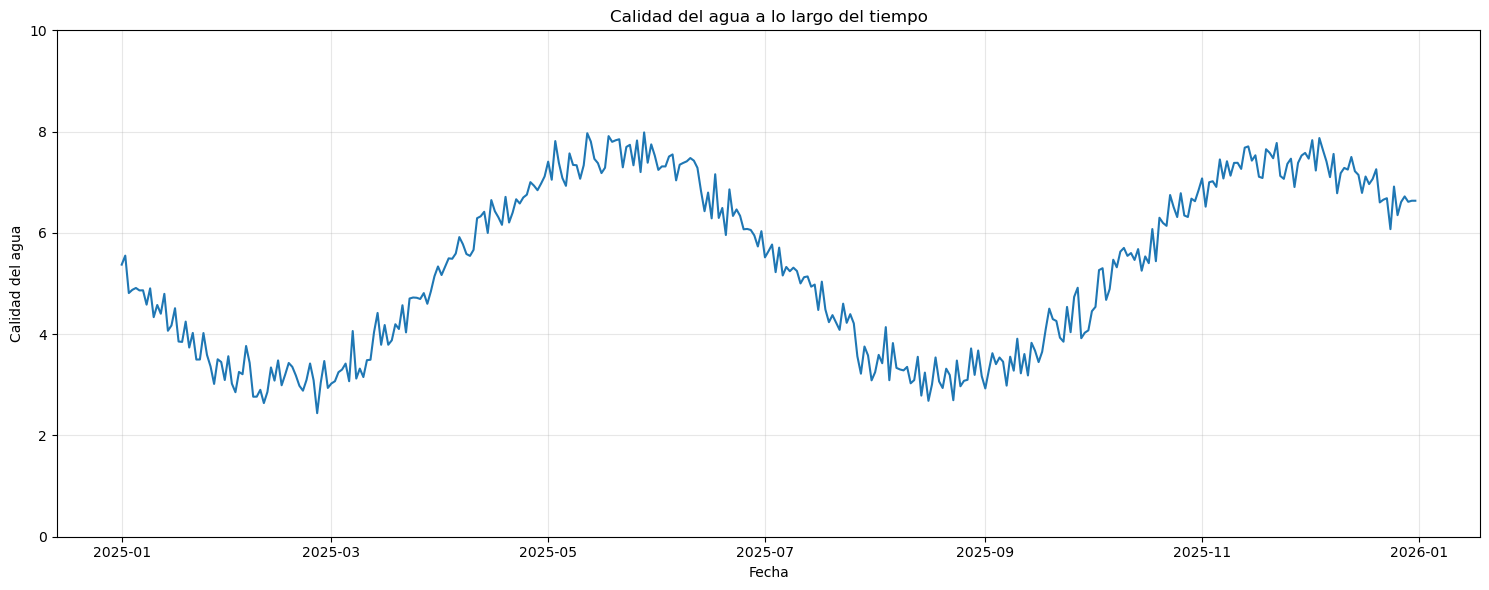

In [ ]:

# GRÁFICA DE LA CALIDAD DEL AGUA diario

plt.figure(figsize=(15, 6))

plt.plot(
    df_diario["fecha"],
    df_diario["calidad_agua"],
    linewidth=1.5
)

plt.title("Calidad del agua a lo largo del tiempo")

plt.xlabel("Fecha")
plt.ylabel("Calidad del agua")

plt.ylim(0, 10)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

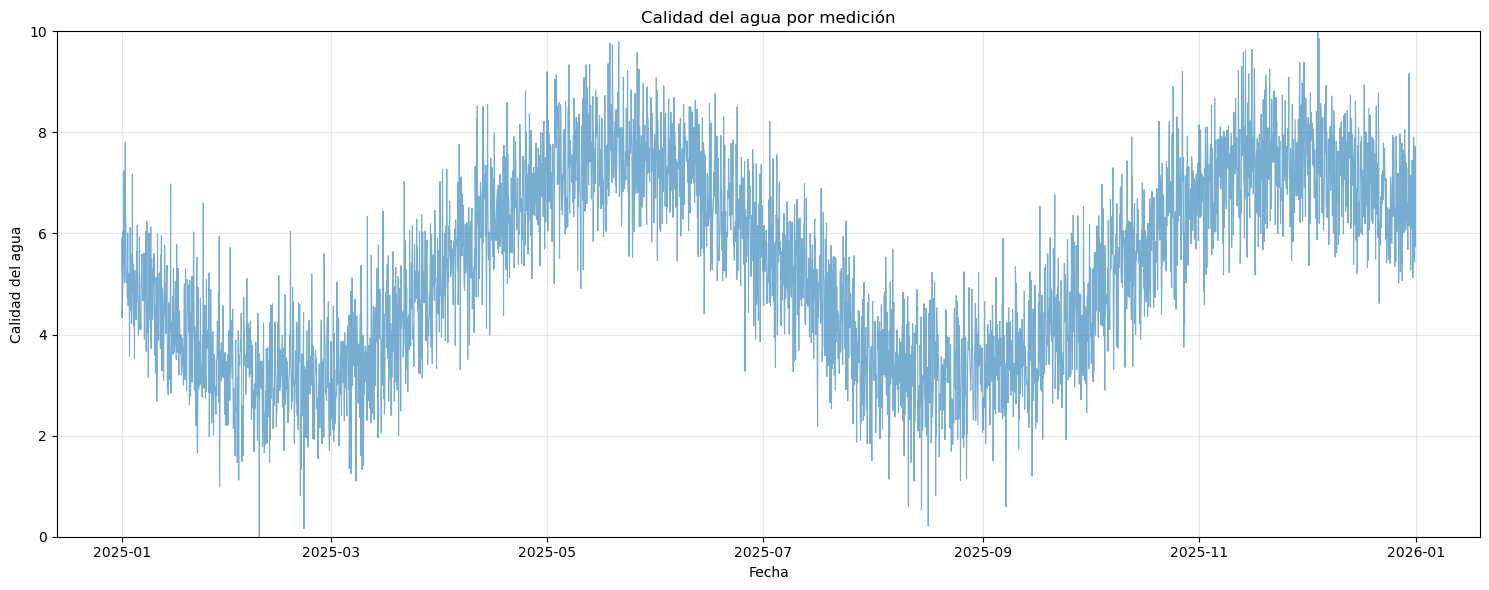

In [ ]:
# grafica de cada muestra
plt.figure(figsize=(15, 6))

plt.plot(
    df["fecha"],
    df["calidad_agua"],
    alpha=0.6,
    linewidth=0.8
)

plt.title("Calidad del agua por medición")

plt.xlabel("Fecha")
plt.ylabel("Calidad del agua")

plt.ylim(0, 10)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:

# GUARDAR DATASET

df.to_csv(
    "calidad_agua_sintetica.csv",
    index=False
)

print("Dataset guardado correctamente.")

Dataset guardado correctamente.


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import copy
import random

In [36]:

# CONFIGURACIÓN GENERAL

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [37]:

# HIPERPARÁMETROS

SEQUENCE_LENGTH = 30

BATCH_SIZE = 64

HIDDEN_SIZE = 64

NUM_LAYERS = 2

DROPOUT = 0.2

LEARNING_RATE = 0.001

EPOCHS = 100

PATIENCE = 10

In [38]:

# VARIABLES DE ENTRADA Y SALIDA

FEATURES = [
    "ph",
    "turbidez",
    "color",
    "sdt",
    "no3",
    "arsenico",
    "plomo",
    "ecoli"
]

TARGET = "calidad_agua"


print("Características:")
print(FEATURES)

print("\nVariable objetivo:")
print(TARGET)

Características:
['ph', 'turbidez', 'color', 'sdt', 'no3', 'arsenico', 'plomo', 'ecoli']

Variable objetivo:
calidad_agua


In [39]:
df["fecha"] = pd.to_datetime(df["fecha"])

df = df.sort_values("fecha").reset_index(drop=True)

print(df[["fecha"] + FEATURES + [TARGET]].head())

                          fecha    ph  turbidez  color     sdt    no3  \
0 2025-01-01 00:00:00.000000000  7.57      2.20   6.01  408.42  25.32   
1 2025-01-01 02:24:00.000000000  7.48      2.29   6.24  512.07  27.58   
2 2025-01-01 04:48:00.000000000  7.60      2.25   6.34  501.63  21.39   
3 2025-01-01 07:11:59.999999999  7.74      1.62   7.55  470.47  22.12   
4 2025-01-01 09:36:00.000000000  7.48      2.12   7.74  411.77  11.60   

   arsenico    plomo  ecoli  calidad_agua  
0   0.00531  0.00336      0          5.91  
1   0.00317  0.00341      0          4.33  
2   0.00329  0.00538      0          4.57  
3   0.00423  0.00214      0          5.01  
4   0.00367  0.00267      0          6.04  


In [40]:

# DIVISIÓN CRONOLÓGICA

n = len(df)

train_end = int(n * 0.70)

val_end = int(n * 0.85)


df_train = df.iloc[:train_end].copy()

df_val = df.iloc[train_end:val_end].copy()

df_test = df.iloc[val_end:].copy()


print("Train:", len(df_train))
print("Validation:", len(df_val))
print("Test:", len(df_test))

Train: 2555
Validation: 547
Test: 548


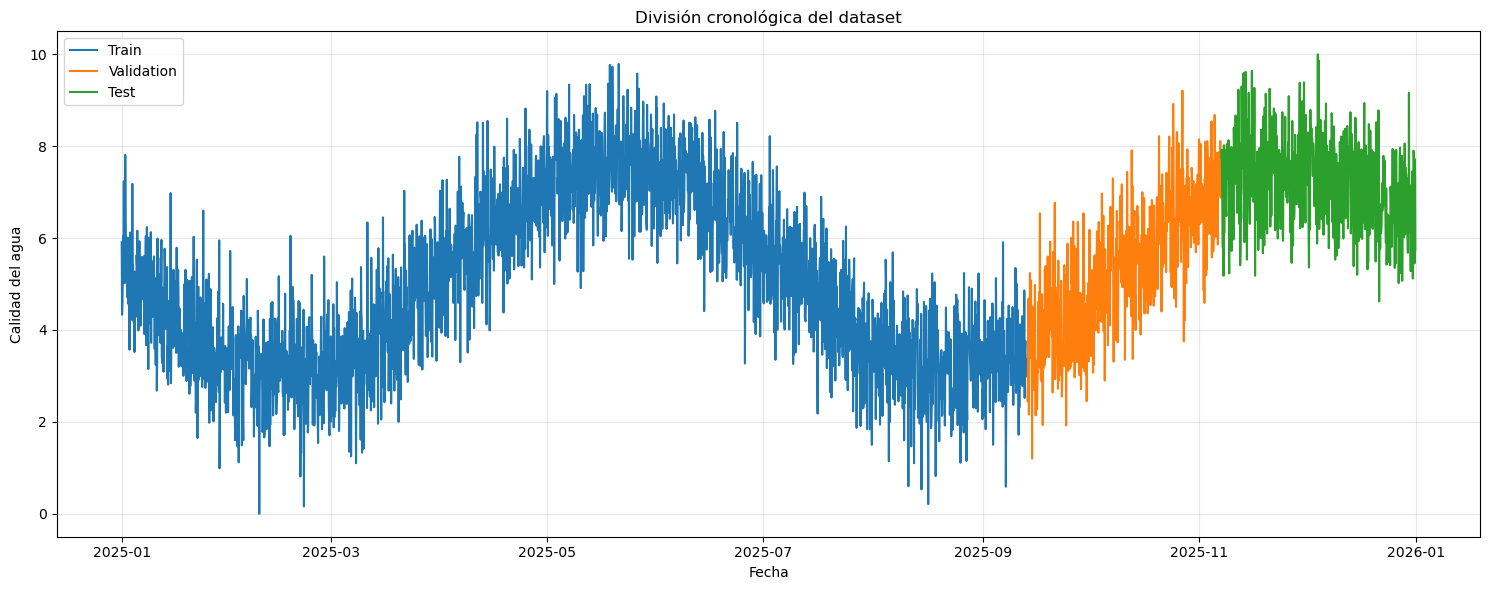

In [41]:
plt.figure(figsize=(15, 6))

plt.plot(
    df_train["fecha"],
    df_train[TARGET],
    label="Train"
)

plt.plot(
    df_val["fecha"],
    df_val[TARGET],
    label="Validation"
)

plt.plot(
    df_test["fecha"],
    df_test[TARGET],
    label="Test"
)

plt.xlabel("Fecha")
plt.ylabel("Calidad del agua")

plt.title("División cronológica del dataset")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:

# NORMALIZACIÓN

scaler_X = StandardScaler()

scaler_y = StandardScaler()

In [43]:
scaler_X.fit(
    df_train[FEATURES]
)

scaler_y.fit(
    df_train[[TARGET]]
)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [44]:
X_train = scaler_X.transform(
    df_train[FEATURES]
)

X_val = scaler_X.transform(
    df_val[FEATURES]
)

X_test = scaler_X.transform(
    df_test[FEATURES]
)


y_train = scaler_y.transform(
    df_train[[TARGET]]
)

y_val = scaler_y.transform(
    df_val[[TARGET]]
)

y_test = scaler_y.transform(
    df_test[[TARGET]]
)

In [45]:
def crear_secuencias(X, y, sequence_length):

    X_seq = []
    y_seq = []

    for i in range(len(X) - sequence_length):

        inicio = i
        fin = i + sequence_length

        X_seq.append(
            X[inicio:fin]
        )

        y_seq.append(
            y[fin]
        )

    return (
        np.array(X_seq, dtype=np.float32),
        np.array(y_seq, dtype=np.float32)
    )

In [46]:
X_train_seq, y_train_seq = crear_secuencias(
    X_train,
    y_train,
    SEQUENCE_LENGTH
)

X_val_seq, y_val_seq = crear_secuencias(
    X_val,
    y_val,
    SEQUENCE_LENGTH
)

X_test_seq, y_test_seq = crear_secuencias(
    X_test,
    y_test,
    SEQUENCE_LENGTH
)


print("X train:", X_train_seq.shape)
print("y train:", y_train_seq.shape)

X train: (2525, 30, 8)
y train: (2525, 1)


In [47]:
class WaterDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )


    def __len__(self):
        return len(self.X)


    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [48]:
train_dataset = WaterDataset(
    X_train_seq,
    y_train_seq
)

val_dataset = WaterDataset(
    X_val_seq,
    y_val_seq
)

test_dataset = WaterDataset(
    X_test_seq,
    y_test_seq
)

In [49]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [50]:
class WaterRNN(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        dropout,
        model_type="LSTM"
    ):

        super().__init__()

        self.model_type = model_type


        if model_type == "RNN":

            self.rnn = nn.RNN(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout
                if num_layers > 1
                else 0
            )


        elif model_type == "LSTM":

            self.rnn = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout
                if num_layers > 1
                else 0
            )


        elif model_type == "GRU":

            self.rnn = nn.GRU(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout
                if num_layers > 1
                else 0
            )

        else:
            raise ValueError(
                "model_type debe ser RNN, LSTM o GRU"
            )


        self.fc = nn.Sequential(

            nn.Linear(
                hidden_size,
                32
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                32,
                1
            )
        )


    def forward(self, x):

        output, _ = self.rnn(x)

        # Último instante temporal
        ultimo_estado = output[:, -1, :]

        prediction = self.fc(
            ultimo_estado
        )

        return prediction

In [51]:
def entrenar_modelo(
    model,
    train_loader,
    val_loader,
    epochs=100,
    learning_rate=0.001,
    patience=10
):

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-5
    )


    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=4
    )


    train_losses = []

    val_losses = []


    best_val_loss = float("inf")

    best_model = None

    epochs_without_improvement = 0


    for epoch in range(epochs):

        # TRAIN

        model.train()

        train_loss = 0


        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(DEVICE)

            y_batch = y_batch.to(DEVICE)


            optimizer.zero_grad()


            predictions = model(
                X_batch
            )


            loss = criterion(
                predictions,
                y_batch
            )


            loss.backward()


            # Evitar exploding gradients
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )


            optimizer.step()


            train_loss += (
                loss.item()
                * X_batch.size(0)
            )


        train_loss /= len(
            train_loader.dataset
        )


        # VALIDATION

        model.eval()

        val_loss = 0


        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(DEVICE)

                y_batch = y_batch.to(DEVICE)


                predictions = model(
                    X_batch
                )


                loss = criterion(
                    predictions,
                    y_batch
                )


                val_loss += (
                    loss.item()
                    * X_batch.size(0)
                )


        val_loss /= len(
            val_loader.dataset
        )


        train_losses.append(
            train_loss
        )

        val_losses.append(
            val_loss
        )


        scheduler.step(
            val_loss
        )


        print(
            f"Epoch {epoch + 1:03d} | "
            f"Train: {train_loss:.6f} | "
            f"Val: {val_loss:.6f}"
        )


        # EARLY STOPPING

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_model = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0


        else:

            epochs_without_improvement += 1


        if epochs_without_improvement >= patience:

            print(
                "\nEarly stopping activado."
            )

            break


    model.load_state_dict(
        best_model
    )


    return (
        model,
        train_losses,
        val_losses
    )

In [52]:
def evaluar_modelo(
    model,
    data_loader,
    scaler_y
):

    model.eval()

    predictions = []

    targets = []


    with torch.no_grad():

        for X_batch, y_batch in data_loader:

            X_batch = X_batch.to(
                DEVICE
            )


            pred = model(
                X_batch
            )


            predictions.extend(
                pred.cpu().numpy()
            )

            targets.extend(
                y_batch.numpy()
            )


    predictions = np.array(
        predictions
    )

    targets = np.array(
        targets
    )


    # Regresar a la escala original
    predictions = scaler_y.inverse_transform(
        predictions
    )

    targets = scaler_y.inverse_transform(
        targets
    )


    mae = mean_absolute_error(
        targets,
        predictions
    )


    rmse = np.sqrt(
        mean_squared_error(
            targets,
            predictions
        )
    )


    r2 = r2_score(
        targets,
        predictions
    )


    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "predictions": predictions,
        "targets": targets
    }

In [53]:
model_types = [
    "RNN",
    "LSTM",
    "GRU"
]


modelos = {}

resultados = {}

In [54]:
for model_type in model_types:

    print("\n")
    print("=" * 60)
    print(
        f"ENTRENANDO MODELO: {model_type}"
    )
    print("=" * 60)


    model = WaterRNN(

        input_size=len(FEATURES),

        hidden_size=HIDDEN_SIZE,

        num_layers=NUM_LAYERS,

        dropout=DROPOUT,

        model_type=model_type

    ).to(DEVICE)


    model, train_losses, val_losses = entrenar_modelo(

        model,

        train_loader,

        val_loader,

        epochs=EPOCHS,

        learning_rate=LEARNING_RATE,

        patience=PATIENCE

    )


    metricas = evaluar_modelo(

        model,

        test_loader,

        scaler_y

    )


    modelos[model_type] = model


    resultados[model_type] = {

        "MAE": metricas["MAE"],

        "RMSE": metricas["RMSE"],

        "R2": metricas["R2"],

        "train_losses": train_losses,

        "val_losses": val_losses,

        "predictions": metricas["predictions"],

        "targets": metricas["targets"]

    }



ENTRENANDO MODELO: RNN
Epoch 001 | Train: 1.142738 | Val: 0.493169
Epoch 002 | Train: 0.560103 | Val: 1.089554
Epoch 003 | Train: 0.547027 | Val: 0.474442
Epoch 004 | Train: 0.379152 | Val: 0.973488
Epoch 005 | Train: 0.370165 | Val: 0.576259
Epoch 006 | Train: 0.350568 | Val: 0.466226
Epoch 007 | Train: 0.377887 | Val: 1.533837
Epoch 008 | Train: 0.442826 | Val: 0.367651
Epoch 009 | Train: 0.361552 | Val: 0.789991
Epoch 010 | Train: 0.326648 | Val: 1.494166
Epoch 011 | Train: 0.322658 | Val: 0.433541
Epoch 012 | Train: 0.331574 | Val: 0.724595
Epoch 013 | Train: 0.363317 | Val: 0.750418
Epoch 014 | Train: 0.319528 | Val: 0.373450
Epoch 015 | Train: 0.293526 | Val: 0.498738
Epoch 016 | Train: 0.278849 | Val: 0.480613
Epoch 017 | Train: 0.272157 | Val: 0.389516
Epoch 018 | Train: 0.277952 | Val: 0.425228

Early stopping activado.


ENTRENANDO MODELO: LSTM
Epoch 001 | Train: 1.036006 | Val: 0.593405
Epoch 002 | Train: 0.785315 | Val: 0.544575
Epoch 003 | Train: 0.443423 | Val: 0.544287

In [55]:
comparacion = pd.DataFrame({

    modelo: {

        "MAE": resultados[modelo]["MAE"],

        "RMSE": resultados[modelo]["RMSE"],

        "R2": resultados[modelo]["R2"]

    }

    for modelo in model_types

}).T


comparacion

,MAE,RMSE,R2
RNN,1.832082,2.060709,-3.791402
LSTM,1.220233,1.466155,-1.425432
GRU,1.351373,1.584571,-1.833040


In [56]:
mejor_modelo_nombre = comparacion[
    "RMSE"
].idxmin()


mejor_modelo = modelos[
    mejor_modelo_nombre
]


print(
    "Mejor modelo:",
    mejor_modelo_nombre
)

print(
    comparacion.loc[
        mejor_modelo_nombre
    ]
)

Mejor modelo: LSTM
MAE     1.220233
RMSE    1.466155
R2     -1.425432
Name: LSTM, dtype: float64


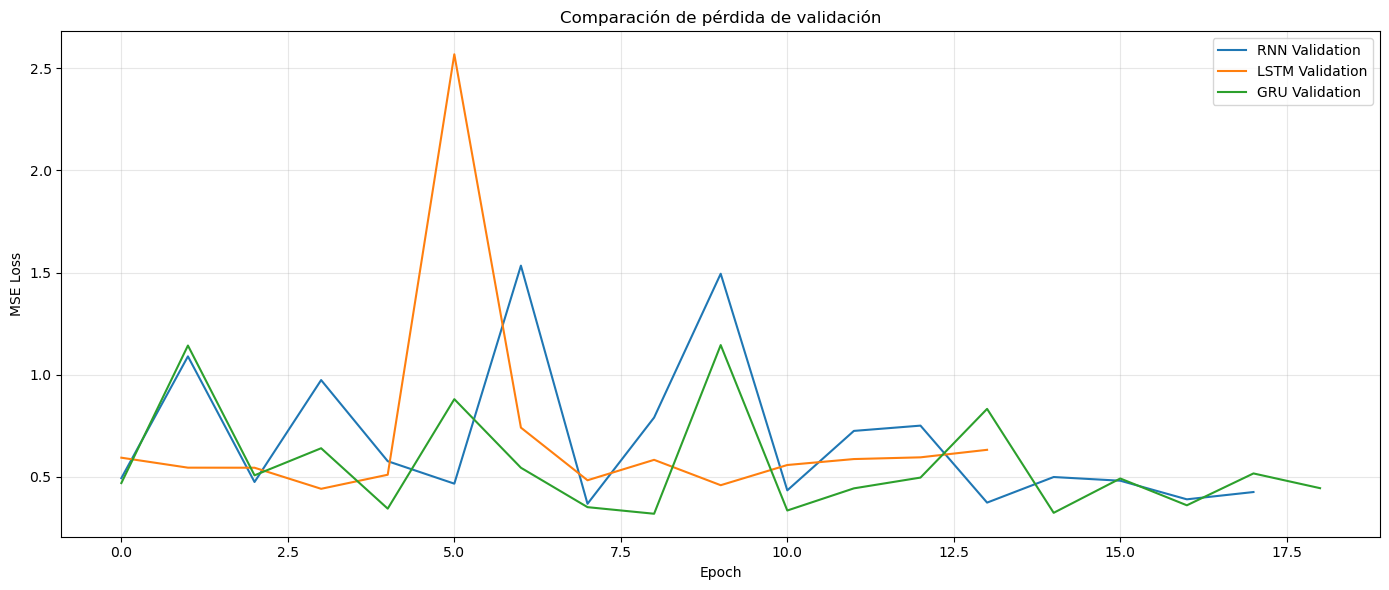

In [57]:
plt.figure(figsize=(14, 6))

for modelo in model_types:

    plt.plot(
        resultados[modelo][
            "val_losses"
        ],
        label=f"{modelo} Validation"
    )


plt.title(
    "Comparación de pérdida de validación"
)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [58]:
predicciones = resultados[
    mejor_modelo_nombre
]["predictions"]

reales = resultados[
    mejor_modelo_nombre
]["targets"]

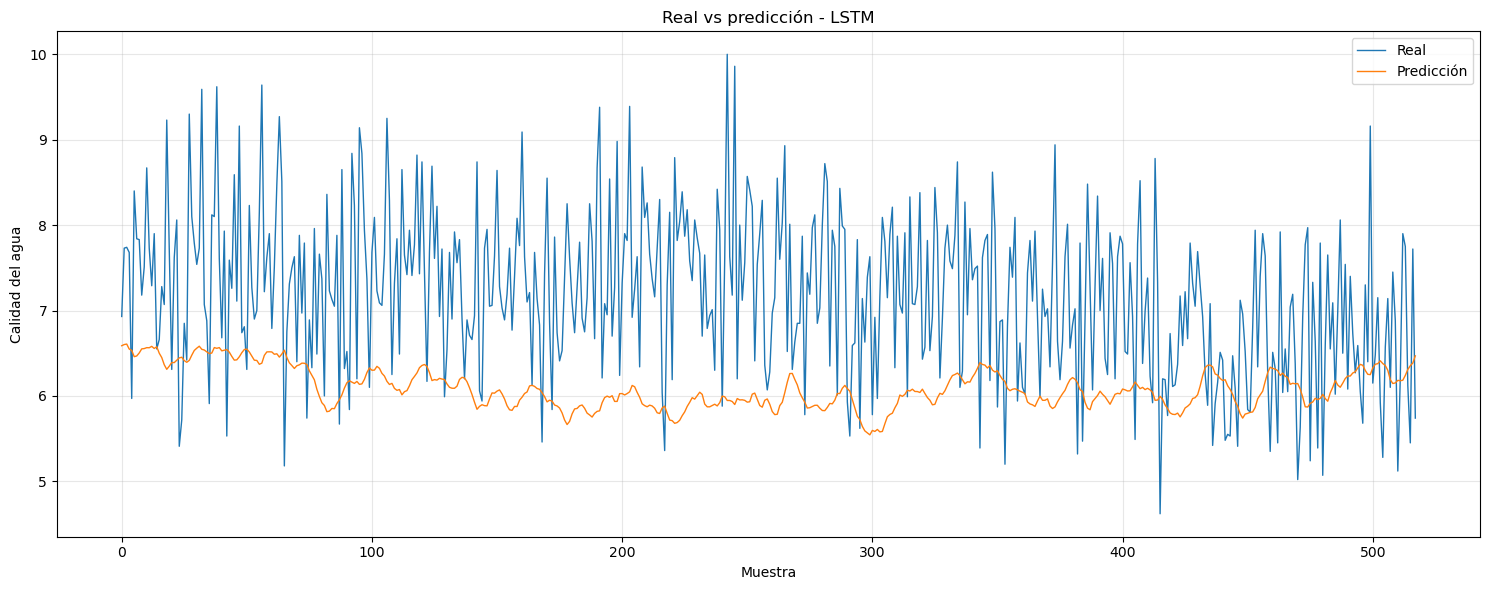

In [59]:
plt.figure(figsize=(15, 6))

plt.plot(
    reales,
    label="Real",
    linewidth=1
)

plt.plot(
    predicciones,
    label="Predicción",
    linewidth=1
)


plt.xlabel("Muestra")

plt.ylabel(
    "Calidad del agua"
)

plt.title(
    f"Real vs predicción - {mejor_modelo_nombre}"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [60]:
torch.save(
    {
        "model_state_dict":
            mejor_modelo.state_dict(),

        "model_type":
            mejor_modelo_nombre,

        "input_size":
            len(FEATURES),

        "hidden_size":
            HIDDEN_SIZE,

        "num_layers":
            NUM_LAYERS,

        "dropout":
            DROPOUT,

        "features":
            FEATURES,

        "sequence_length":
            SEQUENCE_LENGTH
    },

    "mejor_modelo_calidad_agua.pth"
)

In [61]:
def generar_datos_futuros(
    fecha_inicio,
    fecha_fin,
    n_por_dia
):

    dias = pd.date_range(
        start=fecha_inicio,
        end=fecha_fin,
        freq="D"
    )


    fechas = []


    for dia in dias:

        horas = np.linspace(
            0,
            24,
            n_por_dia,
            endpoint=False
        )


        for hora in horas:

            fechas.append(
                dia
                + pd.Timedelta(
                    hours=float(hora)
                )
            )


    n = len(fechas)

    t = np.arange(n)


    ph = (
        7.5
        + 0.4 * np.sin(t / 150)
        + np.random.normal(
            0,
            0.15,
            n
        )
    )

    ph = np.clip(
        ph,
        6.5,
        9.5
    )


    turbidez = (
        2
        + 1.2 * np.sin(t / 100)
        + np.random.normal(
            0,
            0.5,
            n
        )
    )

    turbidez = np.clip(
        turbidez,
        0,
        7
    )


    color = (
        7
        + 3 * np.sin(t / 200)
        + np.random.normal(
            0,
            1.5,
            n
        )
    )

    color = np.clip(
        color,
        0,
        20
    )


    sdt = (
        450
        + 150 * np.sin(t / 300)
        + np.random.normal(
            0,
            60,
            n
        )
    )

    sdt = np.clip(
        sdt,
        100,
        1200
    )


    no3 = (
        20
        + 8 * np.sin(t / 250)
        + np.random.normal(
            0,
            4,
            n
        )
    )

    no3 = np.clip(
        no3,
        0,
        55
    )


    arsenico = (
        0.004
        + 0.002 * np.sin(t / 180)
        + np.random.normal(
            0,
            0.001,
            n
        )
    )

    arsenico = np.clip(
        arsenico,
        0,
        0.015
    )


    plomo = (
        0.003
        + np.random.normal(
            0,
            0.0015,
            n
        )
    )

    plomo = np.clip(
        plomo,
        0,
        0.015
    )


    ecoli = np.random.choice(
        [0, 1],
        size=n,
        p=[0.97, 0.03]
    )


    df_future = pd.DataFrame({

        "fecha": fechas,

        "ph": ph,

        "turbidez": turbidez,

        "color": color,

        "sdt": sdt,

        "no3": no3,

        "arsenico": arsenico,

        "plomo": plomo,

        "ecoli": ecoli

    })


    return df_future

In [62]:
df_futuro = generar_datos_futuros(

    fecha_inicio="2026-01-01",

    fecha_fin="2026-12-31",

    n_por_dia=N_POR_DIA
)


print(df_futuro.head())

print(
    "\nRegistros futuros:",
    len(df_futuro)
)

                          fecha        ph  turbidez     color         sdt  \
0 2026-01-01 00:00:00.000000000  7.574507  2.204026  6.008462  408.422580   
1 2026-01-01 02:24:00.000000000  7.481927  2.287399  6.242592  512.065246   
2 2026-01-01 04:48:00.000000000  7.602486  2.246385  6.344953  501.627394   
3 2026-01-01 07:11:59.999999999  7.736454  1.623168  7.553489  470.465244   
4 2026-01-01 09:36:00.000000000  7.475542  2.122669  7.744370  411.767351   

         no3  arsenico     plomo  ecoli  
0  25.321374  0.005312  0.003363      0  
1  27.583436  0.003165  0.003410      0  
2  21.388890  0.003291  0.005381      0  
3  22.123208  0.004227  0.002137      0  
4  11.595257  0.003674  0.002666      0  

Registros futuros: 3650


In [63]:
X_futuro = scaler_X.transform(
    df_futuro[FEATURES]
)

In [64]:
X_historial = scaler_X.transform(
    df[FEATURES]
)


X_completo = np.vstack([
    X_historial[
        -SEQUENCE_LENGTH:
    ],

    X_futuro
])

In [65]:
X_futuro_seq = []


for i in range(
    SEQUENCE_LENGTH,
    len(X_completo)
):

    secuencia = X_completo[
        i - SEQUENCE_LENGTH:i
    ]


    X_futuro_seq.append(
        secuencia
    )


X_futuro_seq = np.array(
    X_futuro_seq,
    dtype=np.float32
)


print(
    X_futuro_seq.shape
)

(3650, 30, 8)


In [66]:
mejor_modelo.eval()


X_tensor = torch.tensor(
    X_futuro_seq,
    dtype=torch.float32
).to(DEVICE)


predicciones_futuras = []


with torch.no_grad():

    for i in range(
        0,
        len(X_tensor),
        BATCH_SIZE
    ):

        batch = X_tensor[
            i:i + BATCH_SIZE
        ]


        pred = mejor_modelo(
            batch
        )


        predicciones_futuras.append(
            pred.cpu().numpy()
        )

In [67]:
predicciones_futuras = np.vstack(
    predicciones_futuras
)

predicciones_futuras = scaler_y.inverse_transform(
    predicciones_futuras
)

In [68]:
predicciones_futuras = np.clip(
    predicciones_futuras,
    0,
    10
)

In [69]:
df_futuro[
    "calidad_predicha"
] = predicciones_futuras.flatten()


df_futuro[
    [
        "fecha",
        "calidad_predicha"
    ]
].head(20)

,fecha,calidad_predicha
0,2026-01-01 00:00:00.000000000,6.507259
1,2026-01-01 02:24:00.000000000,6.505145
2,2026-01-01 04:48:00.000000000,6.397626
3,2026-01-01 07:11:59.999999999,6.274444
4,2026-01-01 09:36:00.000000000,6.169123
5,2026-01-01 12:00:00.000000000,6.142261
6,2026-01-01 14:23:59.999999999,6.039631
7,2026-01-01 16:48:00.000000000,6.053143
8,2026-01-01 19:12:00.000000000,6.098383
9,2026-01-01 21:35:59.999999999,6.095050


In [70]:
df_futuro_diario = (

    df_futuro

    .set_index("fecha")

    .resample("D")

    ["calidad_predicha"]

    .mean()

    .reset_index()

)

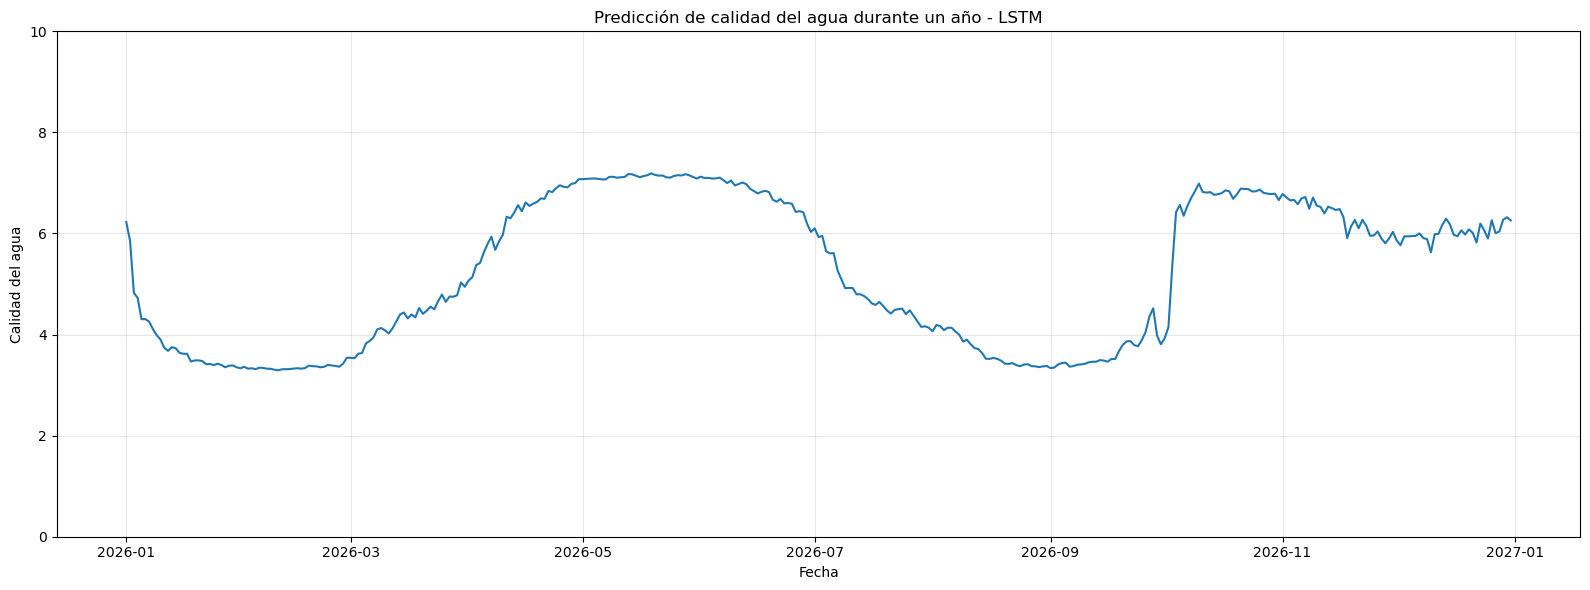

In [71]:
plt.figure(
    figsize=(16, 6)
)


plt.plot(

    df_futuro_diario[
        "fecha"
    ],

    df_futuro_diario[
        "calidad_predicha"
    ],

    linewidth=1.5

)


plt.title(
    f"Predicción de calidad del agua durante un año - {mejor_modelo_nombre}"
)


plt.xlabel(
    "Fecha"
)

plt.ylabel(
    "Calidad del agua"
)


plt.ylim(
    0,
    10
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()

plt.show()

In [72]:
df_futuro.to_csv(
    "prediccion_calidad_agua_1_anio.csv",
    index=False
)

print(
    "Predicción guardada correctamente."
)

Predicción guardada correctamente.
